#

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm # pip install -U statsmodels patsy 
import statsmodels.formula.api as smf
import patsy as pt 

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/finches.csv")

In [3]:
df.head()

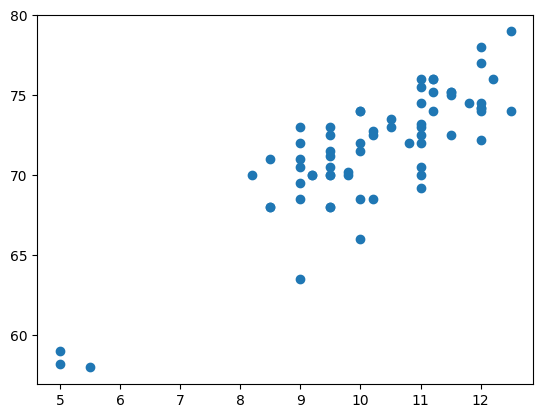

In [5]:
plt.scatter(df["beakwidth"], df["winglength"]);

In [6]:
y, X = pt.dmatrices("winglength ~ beakwidth", data = df) # design matricess

In [17]:
model = smf.ols("winglength ~ island + beakwidth", data = df)
fit = model.fit()

In [18]:
fit.summary()

Notes: [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

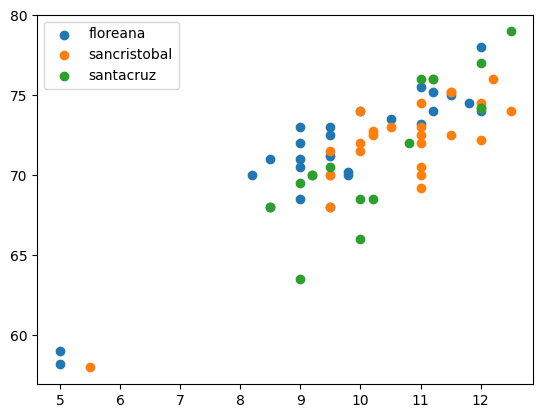

In [24]:
for name, gdf in df.groupby(["island"]):
    plt.scatter(gdf["beakwidth"], gdf["winglength"], label = name[0]);
plt.legend();

In [28]:
xnew = np.array([5, 12])
ndf = pd.DataFrame.from_dict({"beakwidth": xnew, 
                              "island": ["floreana", "floreana"]})
ndf["yhat"] = fit.predict(ndf)
ndf